# S&P 500 Options: Label Engineering

The label is a short straddle's return, and an option position is not a share position:
the thing sold at entry has to be the thing bought back at exit, and it stops existing
on a date fixed when it is sold. This notebook writes that convention down as a formula,
proves each labelled trade has a complete round trip inside one contract, measures how
much independent information overlapping trades carry, establishes the floor a feature
has to clear, and writes the files stage 03 reads.

## Learning objectives

- Express an option label as a round trip in one contract, and say what each leg costs
- Assert - rather than describe - that every labelled window closes on a real quote
- Seal a diagnostic on the date a position settles, not the date it is opened, when the
  settlement date is a property of the contract rather than a fixed offset
- Price the overlap in a label held for a month and sampled every session
- Establish the floor a feature has to clear, under a standard error that prices in that
  overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the daily matched-strike straddle panel and the raw option
chain through `load_sp500_options_straddles()` and `load_sp500_options_straddles_raw()`,
whose coverage [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes,
the underlying closes through `load_sp500_daily_bars()`, and `config/setup.yaml`, which
declares the label set, the cross-validation buffer and the holdout boundary.

Writes five label files - `labels/ret_to_expiry.parquet`, `labels/fwd_ret_5d.parquet`,
`labels/fwd_ret_10d.parquet`, `labels/fwd_ret_dh_5d.parquet` and
`labels/fwd_ret_dh_10d.parquet` - each with a `.digest.json` sidecar beside it.
`03_financial_features.py` reads the primary and `fwd_ret_dh_10d`, `05_evaluation.py`
reads `fwd_ret_dh_10d`, and `90_ic_diagnostic.py` reads `fwd_ret_10d` and
`fwd_ret_dh_10d`. The two intermediate frames the labels are built from,
`labels/contract_returns.parquet` and `labels/hedge_path.parquet`, are produced by
`_label_artifacts.py`, which exists because the round trip below is not a shift.

In [1]:
"""S&P 500 Options: Label Engineering."""

import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.sp500_options._label_artifacts import accrued_hedge_pnl, ensure_label_artifacts
from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "sp500_options"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Both parameters are unset by default, and both are read below - they reach the artifact
builder rather than the frames it returns, because the builder caches its output and a
window applied after the fact would leave the cached full panel in place. `START_DATE`
trims the history to a later start; `MAX_SYMBOLS` keeps the most-quoted symbols only.
Either one shortens a run at the cost of a thinner panel: the rank correlation in Section
G and the cross-sectional dispersion in Section E both need a wide cross-section on each
session to mean anything.

In [2]:
MAX_SYMBOLS = 0
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

The primary label and the four diagnostic variants are declared separately, and the
distinction is what they are for rather than how they are built: models train on
`ret_to_expiry`, while the fixed-horizon variants exist to show what the same trade earns
when it is closed early and when its directional exposure is hedged away. `labels.buffer`
is the gap that keeps a training fold independent of the validation fold after it, and
`generate_cv_splits` takes it separately from the horizon an outcome resolves over -
here they are different quantities, and Section H prints both.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
VARIANT_LABELS = list(setup["labels"]["variant_buffers"])
LABEL_NAMES = [PRIMARY_LABEL, *VARIANT_LABELS]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in VARIANT_LABELS
}
LABEL_BUFFER = setup["labels"]["buffer"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
INSTRUMENT_ID = "straddle_30d_atm"

# One style per label, shared by every figure: the primary in the focal colour, each
# fixed-horizon family in its own, and the delta-hedged member of a family dashed.
SHORT = min(HORIZONS.values(), default=0)
STYLES = {
    name: dict(
        color=COLORS["blue"]
        if name == PRIMARY_LABEL
        else COLORS["amber" if HORIZONS[name] == SHORT else "copper"],
        linestyle="--" if "_dh_" in name else "-",
        lw=2.2 if name == PRIMARY_LABEL else 1.4,
    )
    for name in LABEL_NAMES
}

print(f"Primary {PRIMARY_LABEL}; diagnostic variants {HORIZONS} sessions")
print(f"Cross-validation buffer {LABEL_BUFFER}; holdout opens {HOLDOUT_START}")

Primary ret_to_expiry; diagnostic variants {'fwd_ret_5d': 5, 'fwd_ret_10d': 10, 'fwd_ret_dh_5d': 5, 'fwd_ret_dh_10d': 10} sessions
Cross-validation buffer 35D; holdout opens 2021-01-01


## A. The learning task

The hypothesis is that an option's implied volatility is, on average, above the volatility
the underlying goes on to realise, and that the excess is not uniform across the S&P 500:
some names are priced further above their own subsequent moves than others. Selling a
straddle - one call and one put at the same strike and expiration - is the position that
earns that difference and is close to neutral on direction at the moment it is opened. The
label is therefore the return on a short straddle held over a fixed window, ranked across
names rather than judged in isolation, and the strategy that consumes it sells the names
it ranks highest.

The decision cadence comes from `setup.yaml`: a session's close is observed and the
position is opened at the next session's close, on a straddle written about a month out.
The close is the only price available. AlgoSeek's option chain carries one end-of-session
observation per contract per day - `LastBidPrice`, `LastAskPrice`, `LastMidPrice` and the
matching underlying mid - and no open, high or low, so both the signal and the fill are
quoted at a close and entry is priced at the mid of the next session's quote. A signal
formed at one close and filled at the next is one session late against the 16 to 24
sessions the position is then held for, and Section D reports that exposure window with
the entry session already excluded from it. Carrying the position to expiration fixes the
primary label's outcome: it settles into cash at whatever the underlying is worth that
day. Labels are sampled every session rather than only on Fridays - that buys five times
the rows at the price of overlapping trades, and Section F measures what they are worth.

## B. Preparation before the label

**A forward return on an option is a round trip in one contract, and that is the mistake
this dataset invites.** The daily panel carries a 30-day at-the-money straddle for each
name on each session, but the contract behind that row changes as the calendar moves: the
thing that is 30 days out today is 29 days out tomorrow, so tomorrow's row is a different
strike and often a different expiration. Shifting the panel's price column forward would
difference two prices from two different contracts and report the change of instrument as
profit. What the label needs instead is the price of *today's* contract on a later date,
which only the raw chain holds, so `_label_artifacts.py` looks each held contract up by
`(symbol, strike, expiration)` and returns the entry premium, the exit premium at each
horizon, and the contract's own delta on each day it is held.

The entity a label may not cross is that contract. Entry is at the session after the
signal, so the whole window sits strictly in the future of the row that carries it, and no
eligibility filter runs before the label is built: dropping rows first would make a
forward offset count survivors rather than sessions, and the window would silently span
whatever was removed. Point-in-time liquidity screening is applied downstream, where
`setup.yaml: backtest.sweep.universe_filter` declares it.

In [4]:
ensure_label_artifacts(max_symbols=MAX_SYMBOLS, start_date=START_DATE)
contract_returns = pl.read_parquet(LABELS_DIR / "contract_returns.parquet")
hedge_path = pl.read_parquet(LABELS_DIR / "hedge_path.parquet")
straddles = load_sp500_options_straddles()
underlying = load_sp500_daily_bars()

# Recorded as each label's `inputs`: a re-run against a refreshed download is otherwise
# indistinguishable from this one.
CONTRACT_DIGEST = value_digest(contract_returns)
HEDGE_DIGEST = value_digest(hedge_path)
MARKET_DATA_DIGEST = value_digest(underlying, ["symbol", "timestamp", "close"])

signals = contract_returns["feature_date"]
print(
    f"{contract_returns.height:,} round trips on {contract_returns['symbol'].n_unique()} names, "
    f"signalled {signals.min()} to {signals.max()}\nDigests - contract_returns "
    f"{CONTRACT_DIGEST}, hedge_path {HEDGE_DIGEST}, market_data {MARKET_DATA_DIGEST}"
)

357,479 round trips on 623 names, signalled 2017-01-03 to 2021-12-15
Digests - contract_returns 16ad939fdffd0f9c, hedge_path 24c07ca55f194efa, market_data 666956332393545f


Every window below is counted on the straddle panel's own session calendar, numbered once
here on the source panel rather than on the rows that survive to a label. A name is quoted
on roughly half the sessions in this panel, so counting positions among surviving rows
would make the two rows either side of a gap adjacent and report windows that share
nothing as overlapping.

In [5]:
calendar = straddles.select("timestamp").unique().sort("timestamp").with_row_index("_bar")
N_SESSIONS = calendar.height
# Entry is the session after the signal, so a horizon-h trade closes h+1 sessions out.
calendar = calendar.with_columns(
    (N_SESSIONS - 1 - pl.col("_bar")).alias("from_end"),
    *(
        pl.col("timestamp").shift(-horizon - 1).alias(f"_end_{horizon}d")
        for horizon in set(HORIZONS.values())
    ),
)

panel = contract_returns.rename({"feature_date": "timestamp"}).join(
    calendar, on="timestamp", how="left"
)
print(f"{N_SESSIONS:,} panel sessions; {panel['timestamp'].n_unique():,} carry a signal")

1,259 panel sessions; 1,248 carry a signal


## C. Label construction

One execution convention, written once. A straddle sold at $t{+}1$ for the premium
$P_{t+1} = C_{t+1} + Q_{t+1}$ and bought back $h$ sessions later at $P_{t+1+h}$, with both
prices taken at the mid of the *same* contract, returns

$$r^{(h)}_{i,t} = \frac{P_{i,t+1} - P_{i,t+1+h}}{P_{i,t+1}}$$

for contract $i$. The sign convention is the seller's throughout: a positive number is a
profitable short straddle. The denominator is the premium collected, so the label is
already a return on the capital the trade puts at risk and needs no further scaling.

The delta-hedged variant subtracts the directional part of that P&L. Holding the straddle
leaves a residual exposure $\Delta_d$ to the underlying that changes every day, so the
hedge is rebalanced at each close along the path the contract actually took:

$$r^{(h),\text{dh}}_{i,t} = r^{(h)}_{i,t}
  + \frac{1}{P_{i,t+1}}\sum_{d=1}^{h} \Delta_{i,d-1}\,(S_{i,d} - S_{i,d-1})$$

The delta is the held contract's own, not the panel's constant-maturity delta, which
jumps between contracts daily and would hedge a position nobody holds. `accrued_hedge_pnl`
returns the number of days it found a quote on as well as the accrued P&L, because a sum
over a path with holes is a partial hedge: a label built from one is not the quantity the
formula names, and Section D nulls it rather than presenting it as fully hedged.

The primary label replaces the exit leg altogether. Carried to expiration, the straddle
settles into cash at its intrinsic value and there is no closing trade at all:

$$r^{\text{exp}}_{i,t} = \frac{P_{i,t+1} - |S_{i,T} - K_i|}{P_{i,t+1}}$$

where $K_i$ is the strike, $T$ the expiration, and $S_{i,T}$ the underlying's close that
day. Settlement reads the unadjusted historical close, because the listed strike and the
expiration spot are quoted in the same contemporaneous price basis and adjusting one
without the other would put them on different scales.

**The three conventions divide by the price at entry rather than differencing a price
series, so none of them is a shift, and `fixed_time_horizon_labels` cannot express any of
them.** That is why the round trips are built in `_label_artifacts.py` and read back here.

In [6]:
panel = panel.join(accrued_hedge_pnl(hedge_path), on=["timestamp", "symbol"], how="left")

Each label is then one expression over the round-trip frame, and each carries `_label_end`
- the date its outcome is fully observed. For a fixed-horizon trade that is the session it
is closed on; for the primary label it is the expiration date, which is written into the
contract at entry and varies from trade to trade. Section D checks both against the
calendar, and everything from Section E onwards is sealed on this column.

In [7]:
settlement = underlying.select(
    "symbol",
    pl.col("timestamp").alias("expiration"),
    pl.col("close").alias("_close_at_expiry"),
)
panel = panel.join(settlement, on=["symbol", "expiration"], how="left").with_columns(
    (
        (pl.col("entry_straddle_mid") - (pl.col("_close_at_expiry") - pl.col("strike")).abs())
        / pl.col("entry_straddle_mid")
    ).alias(PRIMARY_LABEL),
    (pl.col("expiration") - pl.col("timestamp"))
    .dt.total_days()
    .cast(pl.Int32)
    .alias("dte_calendar"),
)
for name, horizon in HORIZONS.items():
    exit_mid = pl.col(f"exit_straddle_mid_{horizon}d")
    ret = (pl.col("entry_straddle_mid") - exit_mid) / pl.col("entry_straddle_mid")
    if name.startswith("fwd_ret_dh_"):
        complete = pl.col(f"hedge_days_{horizon}d") == horizon
        hedge = pl.col(f"hedge_pnl_{horizon}d") / pl.col("entry_straddle_mid")
        ret = pl.when(complete).then(ret + hedge)
    panel = panel.with_columns(ret.alias(name))

END_OF = {PRIMARY_LABEL: pl.col("expiration")} | {
    name: pl.col(f"_end_{horizon}d") for name, horizon in HORIZONS.items()
}

The primary label settles on a date the contract fixes rather than a fixed number of
sessions out, so how long the money is committed is itself a distribution. Chapter 7.2
asks for it wherever the resolution time varies: a label whose window is sometimes a third
longer than at other times is not one horizon, and the spread is what the purge gap and
the cost of carry both have to cover.

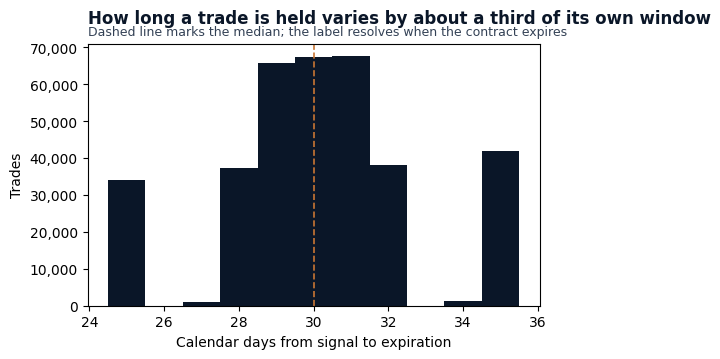

Settlement: 25-35 calendar days, 16-24 sessions of exposure, median 20


In [8]:
# Entry is one session after the signal, so a trade settling on bar e is exposed to the
# e - bar - 1 return intervals realised between them.
expiry_bar = calendar.select(pl.col("timestamp").alias("expiration"), pl.col("_bar").alias("_e"))
panel = panel.join(expiry_bar, on="expiration", how="left").with_columns(
    (pl.col("_e") - pl.col("_bar") - 1).alias("window")
)
resolution = panel.drop_nulls(PRIMARY_LABEL)
PRIMARY_WINDOW = int(resolution["window"].median())
LONGEST_WINDOW = int(resolution["window"].max())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.hist(resolution["dte_calendar"].to_numpy(), bins=np.arange(24.5, 36.5, 1), color=COLORS["blue"])
ax.axvline(resolution["dte_calendar"].median(), color=COLORS["copper"], linestyle="--", lw=1.2)
ax.set_xlabel("Calendar days from signal to expiration")
ax.set_ylabel("Trades")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
add_message_title(
    ax,
    "How long a trade is held varies by about a third of its own window",
    subtitle="Dashed line marks the median; the label resolves when the contract expires",
)
show_with_alt(fig, "Histogram of calendar days between the signal date and expiration.")

print(
    f"Settlement: {resolution['dte_calendar'].min()}-{resolution['dte_calendar'].max()} calendar days, "
    f"{resolution['window'].min()}-{LONGEST_WINDOW} sessions of exposure, "
    f"median {PRIMARY_WINDOW}"
)

## D. Window validity

A join always returns something; the question is whether what it returns is the quantity
the label claims. Each property below fails silently and leaves plausible numbers behind,
so each is asserted rather than described.

The second assertion is a full reconciliation rather than a bound. Every row carrying no
label is attributed to exactly one cause - no premium quoted at entry, no quote for the
held contract on the exit date, a hedge path the contract was not quoted on every day of,
an expiration past the end of the underlying panel, or an expiration on which the
underlying itself did not trade - and the counts have to sum to the height of the frame. A label built from a stale exit, or one that had silently taken
its exit price from a neighbouring contract, would break that identity.

The third assertion is what ties the recorded exit dates to the declared horizons. The
round-trip builder writes each exit date into the artifact, so the notebook can check it
rather than trust it: shifting the panel calendar by the horizon has to land on the same
session, and the whole window has to close on or before the contract expires.

In [9]:
NO_PREMIUM = pl.col("entry_straddle_mid").is_null()
CAUSES = {
    PRIMARY_LABEL: {
        "no entry premium": NO_PREMIUM,
        "expiry past the underlying panel": pl.col("expiration") > underlying["timestamp"].max(),
        "no underlying close at expiry": pl.col("_close_at_expiry").is_null(),
    }
} | {
    name: {
        "no entry premium": NO_PREMIUM,
        "no quote at exit": pl.col(f"exit_straddle_mid_{HORIZONS[name]}d").is_null(),
    }
    | (
        {"incomplete hedge path": pl.col(f"hedge_days_{HORIZONS[name]}d") != HORIZONS[name]}
        if "_dh_" in name
        else {}
    )
    for name in VARIANT_LABELS
}
for name, causes in CAUSES.items():
    # 1. An incomplete window is null, never a value.
    unlabelled = panel.filter(pl.any_horizontal(*causes.values()))
    assert unlabelled[name].null_count() == unlabelled.height, name

    # 2. Labelled rows plus the causes, each counted once, account for every row.
    seen, counts = pl.lit(False), {}
    for cause, cond in causes.items():
        counts[cause] = panel.filter(cond & ~seen).height
        seen = seen | cond
    assert panel.drop_nulls(name).height + sum(counts.values()) == panel.height, (name, counts)

    # 3. Each recorded exit lands where the declared horizon says, inside the contract.
    if name in HORIZONS:
        assert panel.filter(pl.col(f"exit_{HORIZONS[name]}d_date") != END_OF[name]).height == 0
    assert panel.filter(END_OF[name] > pl.col("expiration")).height == 0, name

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert panel.schema[name] == pl.Float64, name

    unlabelled = ", ".join(f"{n:,} {c}" for c, n in counts.items())
    print(f"{name}: {panel.drop_nulls(name).height:,} labelled; unlabelled {unlabelled}")

ret_to_expiry: 354,473 labelled; unlabelled 425 no entry premium, 1,727 expiry past the underlying panel, 854 no underlying close at expiry


fwd_ret_5d: 352,179 labelled; unlabelled 425 no entry premium, 4,875 no quote at exit


fwd_ret_10d: 333,102 labelled; unlabelled 425 no entry premium, 23,952 no quote at exit


fwd_ret_dh_5d: 349,934 labelled; unlabelled 425 no entry premium, 4,875 no quote at exit, 2,245 incomplete hedge path


fwd_ret_dh_10d: 323,847 labelled; unlabelled 425 no entry premium, 23,952 no quote at exit, 9,255 incomplete hedge path


Position zero below is the panel's last session. Every label has to fall to zero over its
own closing window and sit flat before it. A scalar count of valid rows shows neither
failure this catches - a tail fabricated instead of nulled, or a short label masked by a
longer one's null set - and two things it does show here. The primary label recovers much
deeper in than the others, because it needs an expiration the underlying panel still
covers rather than an exit session. And the five- and ten-session labels fall away at the
same depth rather than at their own, because the round-trip builder lays out one set of
exit and hedge dates sized for the longest window it has to fill, and stops every label
where that one runs out. The figure reads only the null structure and never a value, so it
is not sealed.

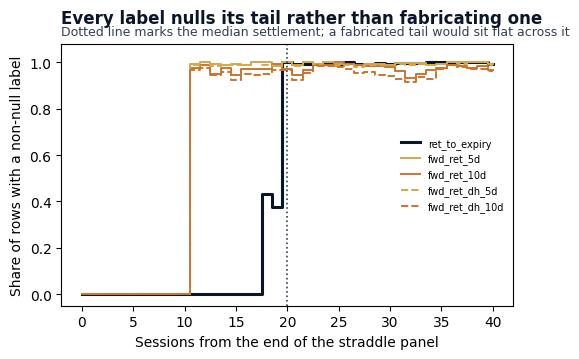

In [10]:
profile = (
    calendar.select("timestamp", "from_end")
    .join(panel.select("timestamp", *LABEL_NAMES), on="timestamp", how="left")
    .filter(pl.col("from_end") <= 40)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in LABEL_NAMES:
    ax.plot(profile["from_end"], profile[name], ds="steps-mid", label=name, **STYLES[name])
ax.axvline(PRIMARY_WINDOW, color=COLORS["neutral"], linestyle=":", lw=1.2)
ax.set_xlabel("Sessions from the end of the straddle panel")
ax.set_ylabel("Share of rows with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Every label nulls its tail rather than fabricating one",
    subtitle="Dotted line marks the median settlement; a fabricated tail would sit flat across it",
)
ax.legend(loc="center right", frameon=False, fontsize=7)
show_with_alt(fig, "Non-null label rate by session position from the end of the straddle panel.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing across names and across regimes?
Everything from here through Section G is computed on the development window only, sealed
on the date each trade **settles** rather than the date its signal is observed. A straddle
sold in the first week of December expires in January, so a filter on the signal date
looks sealed and is not: the holdout's own prices decide the outcome. The label files keep
every row, because the seal governs what this notebook looks at rather than what it
writes.

In [11]:
dev = {
    name: panel.with_columns(END_OF[name].alias("_label_end"))
    .drop_nulls(name)
    .filter(pl.col("_label_end") < HOLDOUT_START)
    for name in LABEL_NAMES
}
for name, frame in dev.items():
    print(f"{name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

ret_to_expiry: 282,470 development rows through 2020-12-04
fwd_ret_5d: 283,065 development rows through 2020-12-22
fwd_ret_10d: 263,863 development rows through 2020-12-15
fwd_ret_dh_5d: 281,047 development rows through 2020-12-22
fwd_ret_dh_10d: 255,773 development rows through 2020-12-15


All five labels go on one axis with identical bins and a logarithmic count axis. The claim
is about shape rather than width: closing the trade early truncates the distribution on
both sides, and hedging the direction away pulls the body in without moving the centre,
while carrying to expiration keeps a loss tail several times the premium collected. The
axis is narrower than the primary label's range, so rows outside it are counted below
rather than drawn.

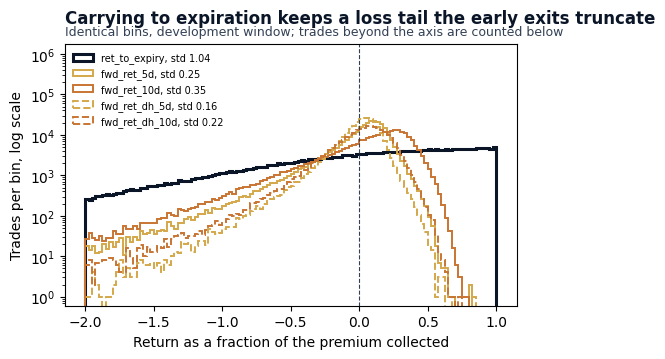

ret_to_expiry: mean -0.0487, std 1.0369, share positive 58.5%, 9,156 beyond the axis
fwd_ret_5d: mean +0.0044, std 0.2507, share positive 64.8%, 246 beyond the axis
fwd_ret_10d: mean +0.0552, std 0.3547, share positive 68.7%, 493 beyond the axis
fwd_ret_dh_5d: mean +0.0003, std 0.1643, share positive 59.6%, 37 beyond the axis
fwd_ret_dh_10d: mean +0.0159, std 0.2182, share positive 61.4%, 109 beyond the axis


In [12]:
bins = np.linspace(-2.0, 1.0, 121)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in LABEL_NAMES:
    series = dev[name][name]
    label = f"{name}, std {series.std():.2f}"
    ax.hist(series.to_numpy(), bins=bins, histtype="step", label=label, **STYLES[name])
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_ylim(top=ax.get_ylim()[1] * 40)
ax.set_xlabel("Return as a fraction of the premium collected")
ax.set_ylabel("Trades per bin, log scale")
add_message_title(
    ax,
    "Carrying to expiration keeps a loss tail the early exits truncate",
    subtitle="Identical bins, development window; trades beyond the axis are counted below",
)
ax.legend(loc="upper left", frameon=False, fontsize=7)
show_with_alt(fig, "Histograms of all five labels on identical bins and a log count axis.")

for name, frame in dev.items():
    beyond = frame.filter(~pl.col(name).is_between(bins[0], bins[-1])).height
    print(
        f"{name}: mean {frame[name].mean():+.4f}, std {frame[name].std():.4f}, "
        f"share positive {(frame[name] > 0).mean():.1%}, {beyond:,} beyond the axis"
    )

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label
ranked across a cross-section, the quantity that has to be stable is the spread the model
ranks within: where it is not, the same rank correlation buys a different amount of
return. The spread is taken across names on each session first and only then averaged over
the year. Pooling every name-session in a year into one standard deviation instead adds
the movement of the panel's own mean from session to session to the spread across names on
a session, and a ranking model is scored on the second alone.

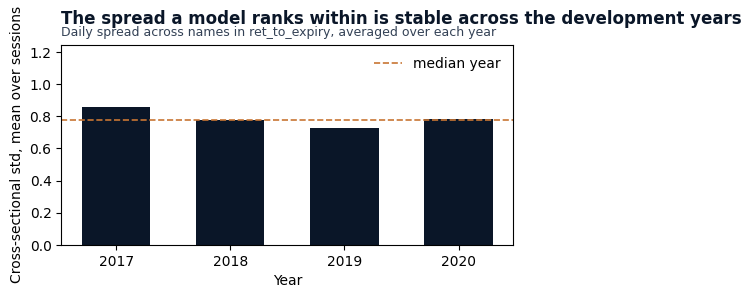

shape: (4, 3)
┌──────┬────────────┬───────┐
│ year ┆ dispersion ┆ names │
│ ---  ┆ ---        ┆ ---   │
│ i32  ┆ f64        ┆ f64   │
╞══════╪════════════╪═══════╡
│ 2017 ┆ 0.860721   ┆ 211.0 │
│ 2018 ┆ 0.775659   ┆ 248.0 │
│ 2019 ┆ 0.727038   ┆ 251.0 │
│ 2020 ┆ 0.783495   ┆ 224.0 │
└──────┴────────────┴───────┘


In [13]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"), pl.len().alias("names"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean(), pl.col("names").median())
    .sort("year")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.6)
ax.axhline(
    annual["dispersion"].median(),
    color=COLORS["copper"],
    linestyle="--",
    lw=1.2,
    label="median year",
)
ax.set_xticks(annual["year"].to_list())
ax.set_ylim(0, annual["dispersion"].max() * 1.45)
ax.set_xlabel("Year")
ax.set_ylabel("Cross-sectional std, mean over sessions")
add_message_title(
    ax,
    "The spread a model ranks within is stable across the development years",
    subtitle=f"Daily spread across names in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-sectional dispersion of the primary label.")

print(annual)

On the development window the hold-to-expiry label has a mean of -0.0487 of the premium
collected against a standard deviation of 1.0369, while 58.5% of trades end profitable:
most positions expire worth keeping and the ones that do not are several times the size of
the ones that do. Closing at ten sessions instead leaves a mean of +0.0552 on a standard
deviation of 0.3547, and hedging that trade's direction away cuts the standard deviation
to 0.2182 while moving the mean to +0.0159 - the hedge takes out the moves in both
directions. Cross-sectional dispersion is steady across the development years, running from
0.727038 in the quietest to 0.860721 in the loudest.

## F. Overlap and effective sample size

Sampling a month-long trade at every session makes consecutive rows share almost all of
their holding window, so the row count overstates the evidence. Two measurements answer
that in different units: how fast the overlap decays, and what the rows are worth once it
is priced in. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting
per name, because concurrency is a property of one name's own overlapping trades.

Both are counted on `_bar`, the panel calendar the windows were built on. A name is quoted
on roughly half the sessions here, and closing over the gaps would pair trades that share
nothing and report the overlap as larger than it is.

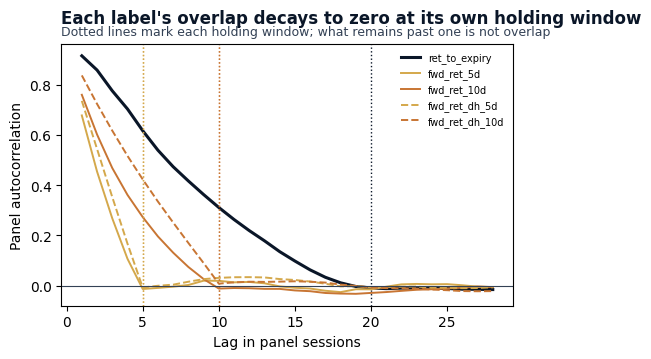

ret_to_expiry: N=282,470, N_eff=22,897, ratio 0.0811 against 0.0500 for windows of 20 sessions overlapping fully; autocorrelation 0.915 at lag one, -0.009 at that lag


fwd_ret_5d: N=283,065, N_eff=69,719, ratio 0.2463 against 0.2000 for windows of 5 sessions overlapping fully; autocorrelation 0.678 at lag one, -0.014 at that lag


fwd_ret_10d: N=263,863, N_eff=39,746, ratio 0.1506 against 0.1000 for windows of 10 sessions overlapping fully; autocorrelation 0.760 at lag one, -0.012 at that lag


fwd_ret_dh_5d: N=281,047, N_eff=69,392, ratio 0.2469 against 0.2000 for windows of 5 sessions overlapping fully; autocorrelation 0.736 at lag one, -0.008 at that lag


fwd_ret_dh_10d: N=255,773, N_eff=39,084, ratio 0.1528 against 0.1000 for windows of 10 sessions overlapping fully; autocorrelation 0.837 at lag one, 0.008 at that lag


In [14]:
max_lag = LONGEST_WINDOW + 4
acf = {
    name: panel_autocorrelation(dev[name], name, max_lag=max_lag, bar_col="_bar")
    for name in LABEL_NAMES
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for name in LABEL_NAMES:
    window = PRIMARY_WINDOW if name == PRIMARY_LABEL else HORIZONS[name]
    ax.plot(lags, acf[name], label=name, **STYLES[name])
    ax.axvline(window, color=STYLES[name]["color"], linestyle=":", lw=1.0)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in panel sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "Each label's overlap decays to zero at its own holding window",
    subtitle="Dotted lines mark each holding window; what remains past one is not overlap",
)
ax.legend(loc="upper right", frameon=False, fontsize=7)
show_with_alt(fig, "Panel autocorrelation of all five labels against lag in panel sessions.")

# A trade exposed for h sessions consumes the h returns realised over them, and the trade
# one session later shares h-1 of those, so average uniqueness converges to 1/h on a dense
# grid. The primary label is weighted by each trade's own window rather than by the median,
# because a median window prices the overlap of a trade none of these rows is.
for name in LABEL_NAMES:
    window = PRIMARY_WINDOW if name == PRIMARY_LABEL else HORIZONS[name]
    per_row = {"horizon_col": "window"} if name == PRIMARY_LABEL else {"horizon": window}
    n_rows, n_eff = effective_sample_size(dev[name], bar_col="_bar", **per_row)
    print(
        f"{name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / window:.4f} for windows of {window} sessions overlapping fully; "
        f"autocorrelation {acf[name][0]:.3f} at lag one, {acf[name][window - 1]:.3f} at that lag"
    )

The primary label's 282,470 development rows carry 22,897 effective observations, a ratio
of 0.0811 against the 0.0500 a fully overlapped 20-session window implies, weighting each
trade by its own exposure rather than by the median. The gap is the panel's own sparsity
rather than a shorter window: a name quoted on half the sessions has fewer concurrent
trades open than a dense grid would give it, and the shorter labels sit above their own
reference values for the same reason - 0.2463 against 0.2000 at five sessions.
Autocorrelation falls from 0.915 at lag one to -0.009 at the median window, so a purge
shorter than the exposure would leave training and validation sharing an outcome. That gap
is set by the window itself, not by these counts.

## G. Baseline floor

One signal against the primary label on the sealed development window, with no feature
engineering: the variance risk premium the hypothesis names, computed as the difference
between the at-the-money implied volatility quoted on the signal date and the volatility
the underlying realised over the previous month. Realised volatility is measured on
split-adjusted closes within stable `sec_id` segments, so a corporate action resetting the
adjustment factor cannot masquerade as a market move. Measuring the floor before building
features is what makes a later improvement meaningful.

The information coefficient is the cross-sectional rank correlation on each session,
averaged over sessions, which is the quantity a ranking model is scored on; pooling every
name-session instead mixes a cross-sectional claim with a time-series one. The library call
returns its series ordered by time, which the standard error depends on. The minimum
cross-section is half the median rather than a bare count, so it means the same thing on a
universe of another size. The standard error is HAC-adjusted, because the IC series
inherits the label's overlap and a naive statistic would treat a month of consecutive
sessions as a month of independent evidence; the bandwidth is set from the longest window
any trade runs for, so it covers every overlap the series carries rather than half of them.

In [15]:
annualised_rv = pl.col("clean_log_return").rolling_std(21).over(["symbol", "sec_id"]) * np.sqrt(252)
realised = (
    reconcile_underlying_log_returns(underlying)
    .sort(["symbol", "sec_id", "timestamp"])
    .with_columns(annualised_rv.alias("rv_21d"))
)
baseline = (
    straddles.select(["timestamp", "symbol", "iv_atm"])
    .join(
        realised.select(["timestamp", "symbol", "rv_21d"]).drop_nulls(), on=["timestamp", "symbol"]
    )
    .with_columns((pl.col("iv_atm") - pl.col("rv_21d")).alias("vrp_proxy"))
    .join(
        dev[PRIMARY_LABEL].select(["timestamp", "symbol", PRIMARY_LABEL]),
        on=["timestamp", "symbol"],
    )
    .drop_nulls(["vrp_proxy", PRIMARY_LABEL])
)
median_cross_section = int(baseline.group_by("timestamp").len()["len"].median())
min_obs = median_cross_section // 2

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="vrp_proxy",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=LONGEST_WINDOW)

print(
    f"Baseline: implied minus realised volatility against {PRIMARY_LABEL}, {baseline.height:,} rows"
)
print(f"  median cross-section {median_cross_section} names, minimum {min_obs}")
print(f"  sessions scored {ic.height:,}, mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: implied minus realised volatility against ret_to_expiry, 276,005 rows
  median cross-section 246 names, minimum 123
  sessions scored 968, mean IC -0.0100
  HAC t -1.06 on 23 Bartlett lags, naive t -3.21, p 0.291


The variance risk premium earns a mean information coefficient of -0.0100 against the
hold-to-expiry label over 968 scored sessions on a cross-section of at least 123 names.
The sign is the opposite of what the hypothesis implies: names whose options are priced
furthest above their recent realised volatility are, if anything, the ones whose short
straddles pay least. Under the naive standard error that is a t-statistic of -3.21, which
the Newey-West rule on 23 Bartlett lags reduces to -1.06 with a p-value of 0.291 - the
whole apparent significance was the overlap being counted as evidence. The floor a feature
has to clear is a mean IC of -0.0100 the data cannot separate from zero.

## H. Artifacts and the audit record

Each label is written with a digest sidecar beside it, recording the content digest of the
values written, the row count, the key columns, the notebook that wrote it and the digests
of the artifacts it was built from. That last field is what ties a label to its data
vintage. `instrument_id` stays in the key alongside the name and the date because a symbol
can carry more than one option structure, and it is part of the identity stage 03 joins on.

The folds that train models are derived per label by `case_studies/utils/cv_window.py`
from `config/setup.yaml` and the timeline of the label parquet written here, so which rows
land in these files is what sets where the fold boundaries fall.

In [16]:
KEYS = ["timestamp", "symbol", "instrument_id"]
for name in LABEL_NAMES:
    extra = {"market_data": MARKET_DATA_DIGEST} if name == PRIMARY_LABEL else {}
    inputs = {"contract_returns": CONTRACT_DIGEST} | (
        {"hedge_path": HEDGE_DIGEST} if "_dh_" in name else extra
    )
    # The primary label carries its own settlement date: the notebooks that model it
    # derive each row's label endpoint from it rather than from a fixed horizon.
    columns = [name, "dte_calendar"] if name == PRIMARY_LABEL else [name]
    record = write_artifact(
        panel.drop_nulls(name).select(
            "timestamp", "symbol", pl.lit(INSTRUMENT_ID).alias("instrument_id"), *columns
        ),
        LABELS_DIR / f"{name}.parquet",
        keys=KEYS,
        written_by="02_labels",
        inputs=inputs,
    )
    print(f"{name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

ret_to_expiry.parquet: 354,473 rows, digest f1d926ba6f09f8c8
fwd_ret_5d.parquet: 352,179 rows, digest 07c644a8a105f5e0


fwd_ret_10d.parquet: 333,102 rows, digest 6414058873427591
fwd_ret_dh_5d.parquet: 349,934 rows, digest 89347540486c5062


fwd_ret_dh_10d.parquet: 323,847 rows, digest bbc38febd1f2e6f3


The record Chapter 7.2 requires to close a label definition, one row per label, built from
the values computed above rather than written by hand. The buffer and the outcome horizon
are separate rows because they are separate numbers here: the buffer is declared in
calendar days and has to cover the longest settlement, while the outcome horizon is what
the label's overlap is measured in.

In [17]:
READERS = {
    PRIMARY_LABEL: "03_financial_features.py and every model stage, as labels.primary",
    "fwd_ret_10d": "90_ic_diagnostic.py",
    "fwd_ret_dh_10d": "03_financial_features.py, 05_evaluation.py, 90_ic_diagnostic.py",
}
print(f"\nLabel audit record - cross-validation buffer {LABEL_BUFFER} for every label")
for name in LABEL_NAMES:
    primary, frame = name == PRIMARY_LABEL, dev[name]
    window = PRIMARY_WINDOW if primary else HORIZONS[name]
    exit_leg = "cash settlement at intrinsic value" if primary else "mid of the same contract"
    when = (
        f"variable: {resolution['window'].min()}-{LONGEST_WINDOW} sessions of exposure"
        if primary
        else f"fixed at {window} sessions from entry"
    )
    print(
        f"\n{name}\n  anchor       mid of the straddle sold one session after the signal"
        f"\n  exit         {exit_leg}"
        f"\n  horizon      {window} sessions{' (median)' if primary else ''}"
        f"\n  resolution   {when}"
        f"\n  overlap      {window - 1} sessions shared by consecutive trades in one name"
        f"\n  base rate    mean {frame[name].mean():+.5f}, share positive {(frame[name] > 0).mean():.3f}"
        f"\n  consumed by  {READERS.get(name, 'the diagnostic notebooks, as a variant')}"
    )


Label audit record - cross-validation buffer 35D for every label

ret_to_expiry
  anchor       mid of the straddle sold one session after the signal
  exit         cash settlement at intrinsic value
  horizon      20 sessions (median)
  resolution   variable: 16-24 sessions of exposure
  overlap      19 sessions shared by consecutive trades in one name
  base rate    mean -0.04873, share positive 0.585
  consumed by  03_financial_features.py and every model stage, as labels.primary

fwd_ret_5d
  anchor       mid of the straddle sold one session after the signal
  exit         mid of the same contract
  horizon      5 sessions
  resolution   fixed at 5 sessions from entry
  overlap      4 sessions shared by consecutive trades in one name
  base rate    mean +0.00436, share positive 0.648
  consumed by  the diagnostic notebooks, as a variant

fwd_ret_10d
  anchor       mid of the straddle sold one session after the signal
  exit         mid of the same contract
  horizon      10 session

## Key takeaways

1. **On an option panel, a forward return is a round trip in one contract, not a shift of
   a price column.** The 30-day at-the-money row is a different instrument every session,
   so a shifted difference reports the change of contract as profit. Look the held
   contract up in the raw chain instead.
2. **Reconcile every unlabelled row to one cause.** A missing quote at exit, a premium
   that was never quoted, a hedge path with a hole in it and an expiration past the end
   of the price panel all fail without raising, and a reconciliation that has to balance
   catches what a row count passed over does not.
3. **Seal a diagnostic on the date the position settles.** When the settlement date is
   written into the contract rather than fixed at a number of sessions, that date is the
   boundary - a trade opened before the holdout and expiring inside it is a holdout trade.
4. **A row count overstates the evidence when holding windows overlap.** The effective
   count says by how much in rows, and the same overlap priced into a standard error is
   what turns a t-statistic that reads as decisive into one that cannot be separated from
   zero.
5. **Check the sign of a baseline before assuming its size is the question.** The variance
   risk premium points the opposite way to the hypothesis on this universe, which is a
   fact about the cross-section that a mean-level argument about the premium would miss.

**Known limitations.** Mid-to-mid pricing is not what a trader receives; the entry
half-spread and the commission are swept in `14_costs.py`, and the primary label avoids
the exit half-spread only because cash settlement needs no closing trade. The delta hedge
is rebalanced at the close and charges nothing for doing so. The universe is every name
with a quoted matched-strike straddle, with the liquidity screen applied downstream rather
than here. The baseline is one signal, on one month of realised volatility.

**Next**: `03_financial_features.py` builds the volatility-surface, term-structure and
instrument-state features and evaluates them against these labels.